In [14]:
import geopandas as gpd
from shapely.geometry import Point
from PIL import Image
import numpy as np
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

In [15]:
# Uploading Parkinson's Disease Prevalence and Incidence for Rural-urban Continuum Spreadsheet
uploaded = files.upload()

Saving parkinsons_disease_prevalence_and_indicidence_for_rural-urban_continuum.xlsx to parkinsons_disease_prevalence_and_indicidence_for_rural-urban_continuum (1).xlsx


In [16]:
# Put spreadsheet into Pandas dataframe
df = pd.read_excel('parkinsons_disease_prevalence_and_indicidence_for_rural-urban_continuum.xlsx')

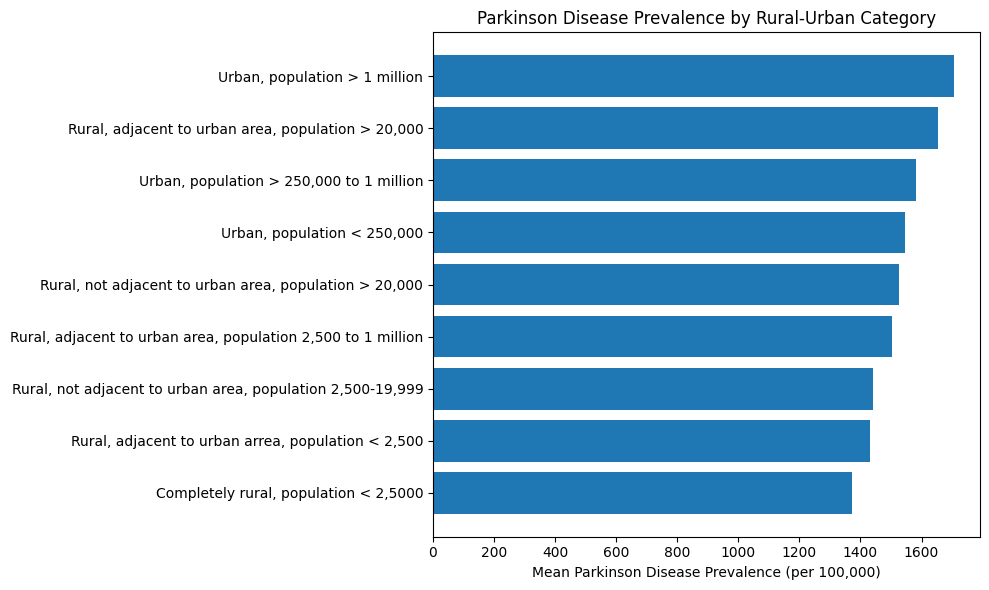

In [17]:
# Sort by Prevalence
df_prev = df.sort_values(by='Mean Parkinson Disease Prevalance (95% CI)', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(df_prev['Rural-urban Continuum'], df_prev['Mean Parkinson Disease Prevalance (95% CI)'])

plt.xlabel('Mean Parkinson Disease Prevalence (per 100,000)')
plt.title('Parkinson Disease Prevalence by Rural-Urban Category')
plt.gca().invert_yaxis()  # highest value at top

plt.tight_layout()
plt.show()

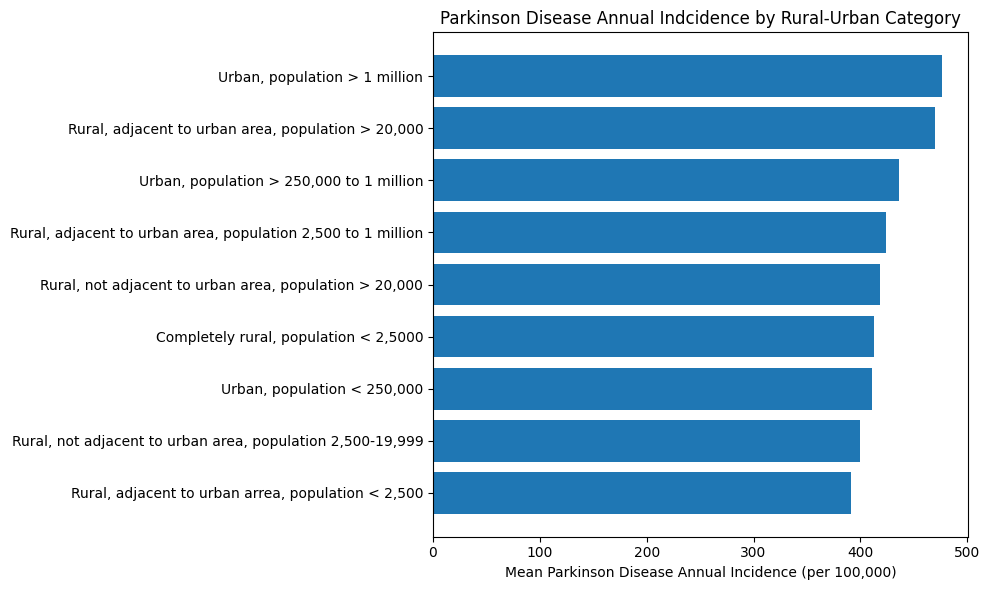

In [18]:
# Sort by Incidence
df_prev = df.sort_values(by='Mean Parkinson Disease Annual Incidence (95% CI)', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(df_prev['Rural-urban Continuum'], df_prev['Mean Parkinson Disease Annual Incidence (95% CI)'])

plt.xlabel('Mean Parkinson Disease Annual Incidence (per 100,000)')
plt.title('Parkinson Disease Annual Indcidence by Rural-Urban Category')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

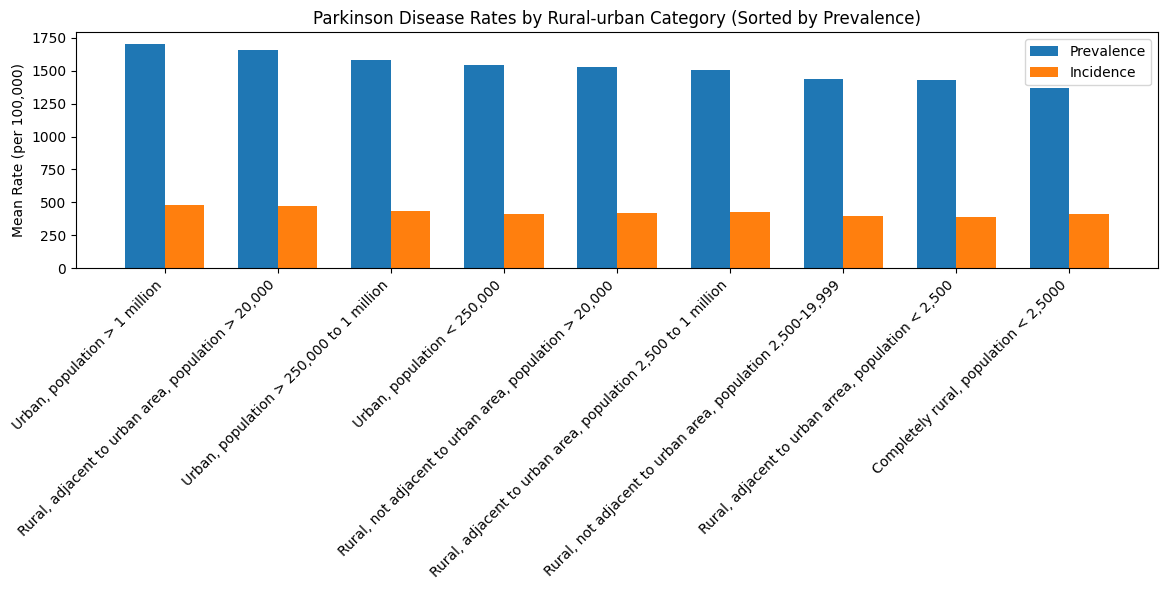

In [19]:
# Sort by prevalence
df_sorted = df.sort_values(by='Mean Parkinson Disease Prevalance (95% CI)', ascending=False)

x = np.arange(len(df_sorted))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, df_sorted['Mean Parkinson Disease Prevalance (95% CI)'], width, label='Prevalence')
plt.bar(x + width/2, df_sorted['Mean Parkinson Disease Annual Incidence (95% CI)'], width, label='Incidence')

plt.xticks(x, df_sorted['Rural-urban Continuum'], rotation=45, ha='right')
plt.ylabel('Mean Rate (per 100,000)')
plt.title('Parkinson Disease Rates by Rural-urban Category (Sorted by Prevalence)')

plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Uploading Parkinson's Incidence by County Spreadsheet
uploaded = files.upload()

Saving parkinsons_incidence_by_county.xlsx to parkinsons_incidence_by_county (1).xlsx


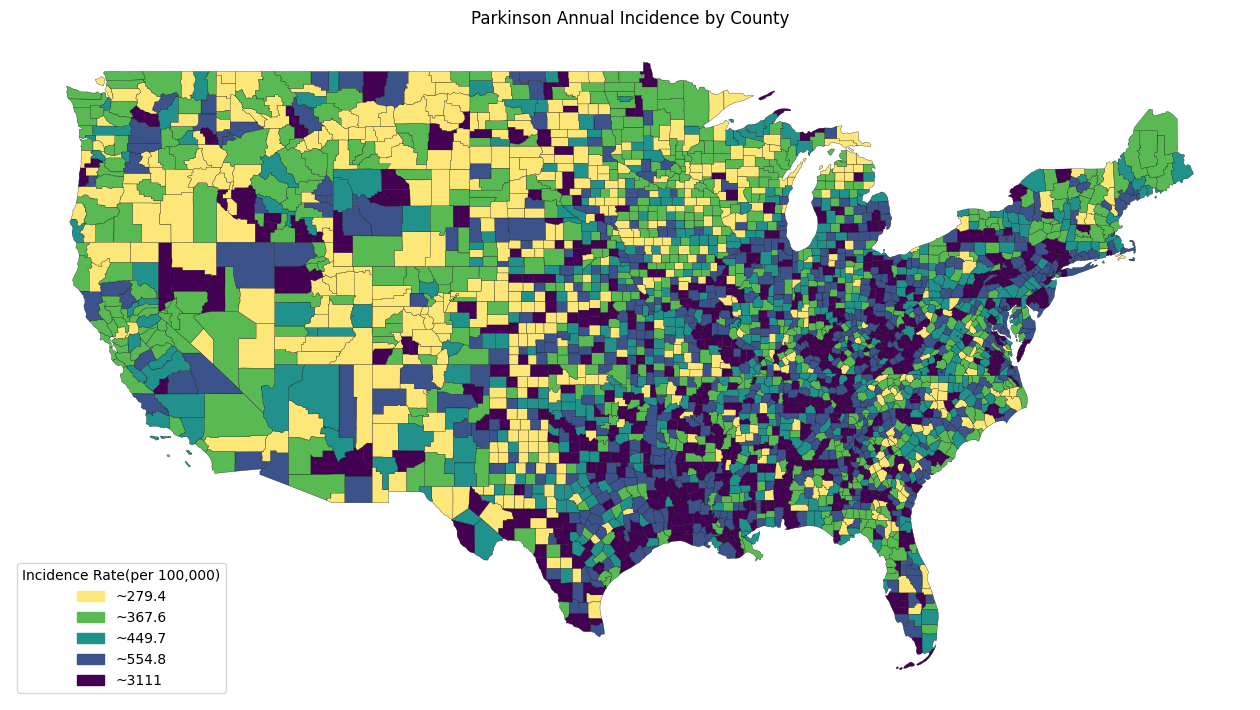

In [21]:
# Place spreadsheet into data frame
df = pd.read_excel("parkinsons_incidence_by_county.xlsx")

# Converts state code to string
df["STATEFP"] = df["STATEFP"].astype(str).str.zfill(2)
# Converts county code to string
df["COUNTYFP"] = df["COUNTYFP"].astype(str).str.zfill(3)
# Creates full ID
df["GEOID"] = df["STATEFP"] + df["COUNTYFP"]

# Converts values to string (just in case)
df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")

# Load map data from census
county_url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_county_20m.zip"
# Read the files from the URL to get the counties
counties = gpd.read_file(county_url)

# Remove our extra territories that were not included in the data
# Remove Hawaii and Alaska for now as they zoom out the map too much
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()

# Use GEOID and value to assign the value to each county
gdf = counties.merge(df[["GEOID", "VALUE"]], on="GEOID", how="left")

# How the colors map to values
#UPDATE: I changed the color pallate to Virdis unstead of rainbow
color_map = {
    # pale yellow
    279.4: (253/255, 231/255, 120/255),
    # light green
    367.6: (89/255, 186/255, 83/255),
    # light blue
    449.7: (33/255, 145/255, 140/255),
    # dark blue
    554.8: (59/255, 82/255, 139/255),
    # dark blue
    3111.0: (68/255, 1/255, 84/255)
}

# Assign the color to each value that is associated with each county
gdf["color"] = gdf["VALUE"].map(color_map)


fig, ax = plt.subplots(figsize=(16, 10))

gdf.plot(
    ax=ax,
    color=gdf["color"],
    linewidth=0.2,
    edgecolor="black"
)

ax.set_title("Parkinson Annual Incidence by County")
ax.axis("off")

# Legend so that the user knows what the colors mean
legend_patches = [
    mpatches.Patch(color=color_map[279.4], label="~279.4"),
    mpatches.Patch(color=color_map[367.6], label="~367.6"),
    mpatches.Patch(color=color_map[449.7], label="~449.7"),
    mpatches.Patch(color=color_map[554.8], label="~554.8"),
    mpatches.Patch(color=color_map[3111.0], label="~3111"),
]

ax.legend(handles=legend_patches, title="Incidence Rate(per 100,000)", loc="lower left")

plt.show()

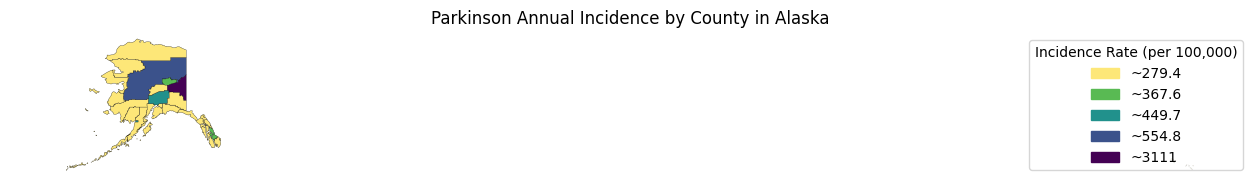

In [22]:
# Read the files from the URL to get the counties
counties2 = gpd.read_file(county_url)

# Keep Alaska
include = ["02"]

counties2 = counties2[counties2["STATEFP"].isin(include)]

# Use GEOID and value to assign the value to each county
gdf = counties2.merge(df[["GEOID", "VALUE"]], on="GEOID", how="left")

# Assign the color to each value that is associated with each county
gdf["color"] = gdf["VALUE"].map(color_map)


fig, ax = plt.subplots(figsize=(16, 10))

gdf.plot(
    ax=ax,
    color=gdf["color"],
    linewidth=0.2,
    edgecolor="black"
)

ax.set_title("Parkinson Annual Incidence by County in Alaska")
ax.axis("off")

ax.legend(handles=legend_patches, title="Incidence Rate (per 100,000)", loc="lower right")

plt.show()

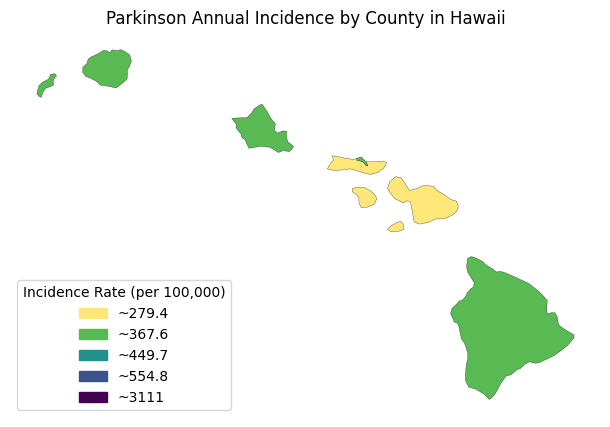

In [23]:
# Read the files from the URL to get the counties
counties2 = gpd.read_file(county_url)

# Keep Hawaii
include = ["15"]

counties2 = counties2[counties2["STATEFP"].isin(include)]

# Use GEOID and value to assign the value to each county
gdf = counties2.merge(df[["GEOID", "VALUE"]], on="GEOID", how="left")

# Assign the color to each value that is associated with each county
gdf["color"] = gdf["VALUE"].map(color_map)


fig, ax = plt.subplots(figsize=(8, 5))

gdf.plot(
    ax=ax,
    color=gdf["color"],
    linewidth=0.2,
    edgecolor="black"
)

ax.set_title("Parkinson Annual Incidence by County in Hawaii")
ax.axis("off")

ax.legend(handles=legend_patches, title="Incidence Rate (per 100,000)", loc="lower left")

plt.show()

PESTICIDE USE GRAPHS

In [24]:
# Load counties
counties = gpd.read_file(county_url)

# Remove territories that are not part of United States
exclude = ["60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()

# Columns we want
area_df = counties[["STATEFP", "COUNTYFP", "NAME", "GEOID", "ALAND"]].copy()

# Convert land area to square miles
area_df["area_sqmi"] = area_df["ALAND"] / 2_589_988.11

# Save to Excel
area_df.to_excel("county_area.xlsx", index=False)

In [25]:
# Uploading county areas
uploaded = files.upload()

Saving county_area.xlsx to county_area (1).xlsx
Saving pesticides_by_county.xlsx to pesticides_by_county.xlsx


In [26]:
# Uploading pesticides by county
uploaded = files.upload()

In [27]:
# Put 2 files into dataframes
area_df = pd.read_excel("county_area.xlsx")
pest_df = pd.read_excel("pesticides_by_county.xlsx")

# Add leading zeros and combine to create GEOIDs
pest_df["STATE_FIPS_CODE"] = pest_df["STATE_FIPS_CODE"].astype(str).str.zfill(2)
pest_df["COUNTY_FIPS_CODE"] = pest_df["COUNTY_FIPS_CODE"].astype(str).str.zfill(3)
pest_df["GEOID"] = pest_df["STATE_FIPS_CODE"] + pest_df["COUNTY_FIPS_CODE"]

# Convert GEOID to string for area so the merge can be done
area_df["GEOID"] = area_df["GEOID"].astype(str).str.zfill(5)

# Merge area into pesticide table
merged_df = pest_df.merge(
    area_df[["GEOID", "NAME", "ALAND", "area_sqmi"]],
    on="GEOID",
    how="left"
)

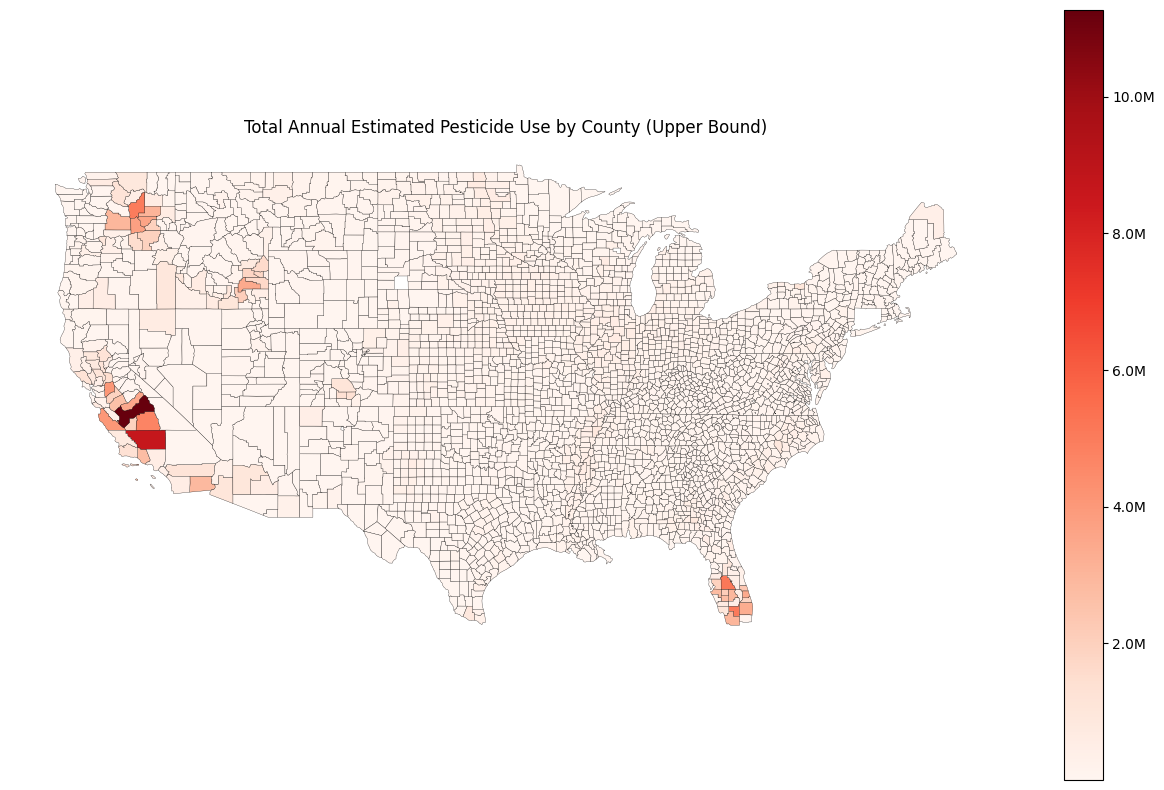

In [28]:
# Make sure upper bound KG and GEOID are numbers
merged_df["EPEST_HIGH_KG"] = pd.to_numeric(merged_df["EPEST_HIGH_KG"])
merged_df["GEOID"] = merged_df["GEOID"].astype(str).str.zfill(5)


# Total pesticide use by county using the upper estimate
total_by_county = (
    merged_df
    # Group the counties, sum the upper bound KG for all pesticides
    .groupby("GEOID", as_index=False)["EPEST_HIGH_KG"]
    .sum()
    .rename(columns={"EPEST_HIGH_KG": "TOTAL_PESTICIDE_KG"})
)

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove bonus territories
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()

# Convert GEOID back to string
counties["GEOID"] = counties["GEOID"].astype(str).str.zfill(5)

# Merge pesticide totals onto counties
gdf_total = counties.merge(total_by_county, on="GEOID", how="left")


fig, ax = plt.subplots(figsize=(16, 10))

gdf_total.plot(
    column="TOTAL_PESTICIDE_KG",
    cmap="Reds",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

# Color bar
cbar = ax.get_figure().axes[-1]
cbar.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax.set_title("Total Annual Estimated Pesticide Use by County (Upper Bound)")
ax.axis("off")

plt.show()

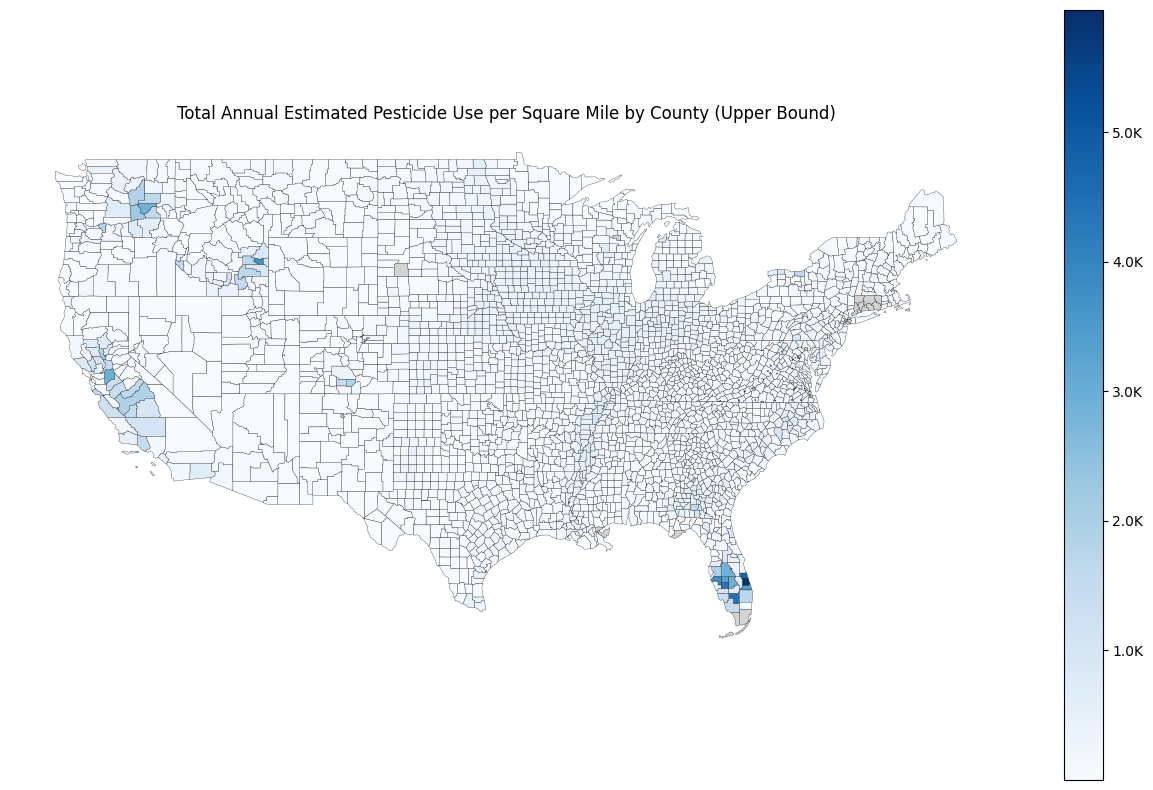

In [29]:
# Convert land area to square miles
gdf_total["area_sqmi"] = gdf_total["ALAND"] / 2_589_988.11

# Compute pesticide per square mile
gdf_total["KG_PER_SQ_MILE"] = (
    gdf_total["TOTAL_PESTICIDE_KG"] / gdf_total["area_sqmi"]
)

fig, ax = plt.subplots(figsize=(16, 10))

gdf_total.plot(
    column="KG_PER_SQ_MILE",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray"},
    ax=ax
)

# Colorbar
import matplotlib.ticker as ticker
cbar = ax.get_figure().axes[-1]
cbar.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}K')  # or /1e6 for M
)

ax.set_title("Total Annual Estimated Pesticide Use per Square Mile by County (Upper Bound)")
ax.axis("off")

bounds = gdf_total.total_bounds

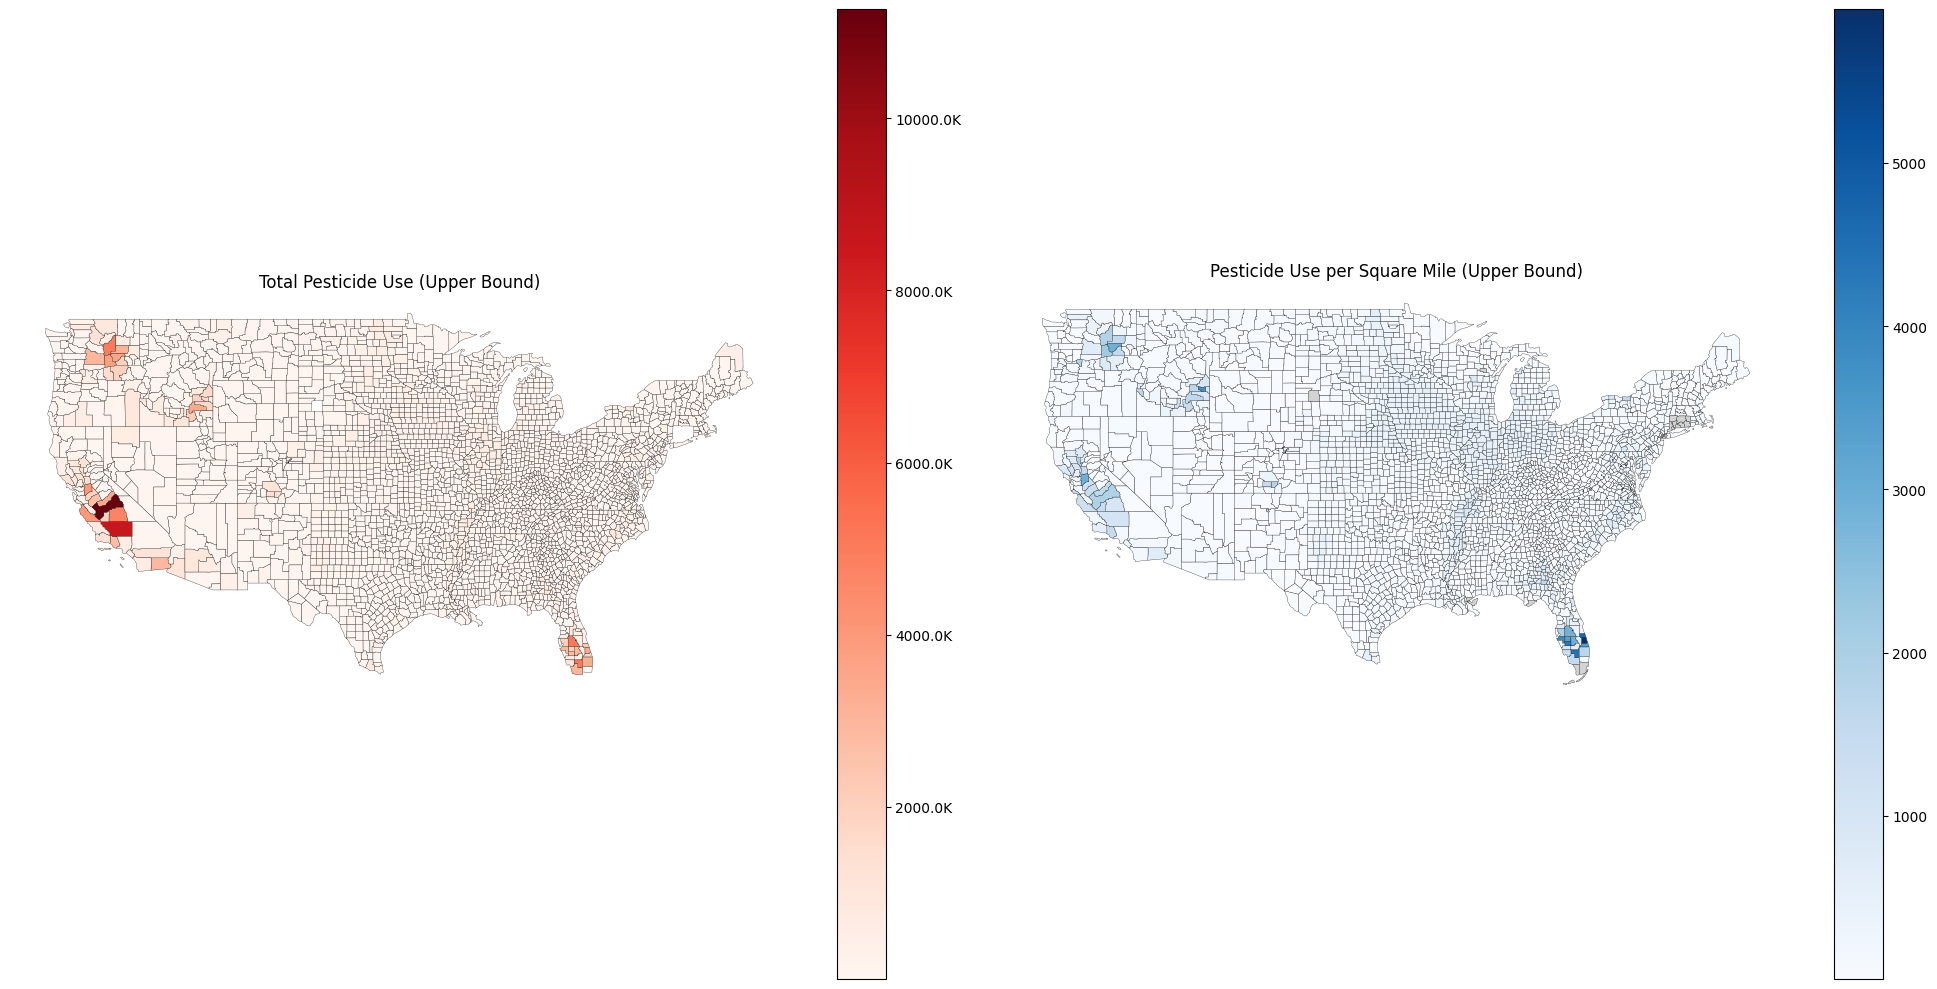

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Total Pesticide Use by County
gdf_total.plot(
    column="TOTAL_PESTICIDE_KG",
    cmap="Reds",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=axes[0]
)

cbar1 = axes[0].get_figure().axes[1]
cbar1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

axes[0].set_title("Total Pesticide Use (Upper Bound)")
axes[0].axis("off")


# Pesticide Use per Square Mile by County
gdf_total.plot(
    column="KG_PER_SQ_MILE",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray"},
    ax=axes[1]
)

cbar2 = axes[1].get_figure().axes[2]
cbar2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}K')
)

axes[1].set_title("Pesticide Use per Square Mile (Upper Bound)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

PESTICIDE BAR GRAPH

In [31]:
# Group all occurrences of each pesticide to get total amount in the United States
# Sort from most used to least used
top_pesticides = (
    merged_df
    .groupby("COMPOUND")["EPEST_HIGH_KG"]
    .sum()
    .sort_values(ascending=False)
)

In [32]:
# We will look at top 9 most used pesticides
top9 = top_pesticides.head(9)

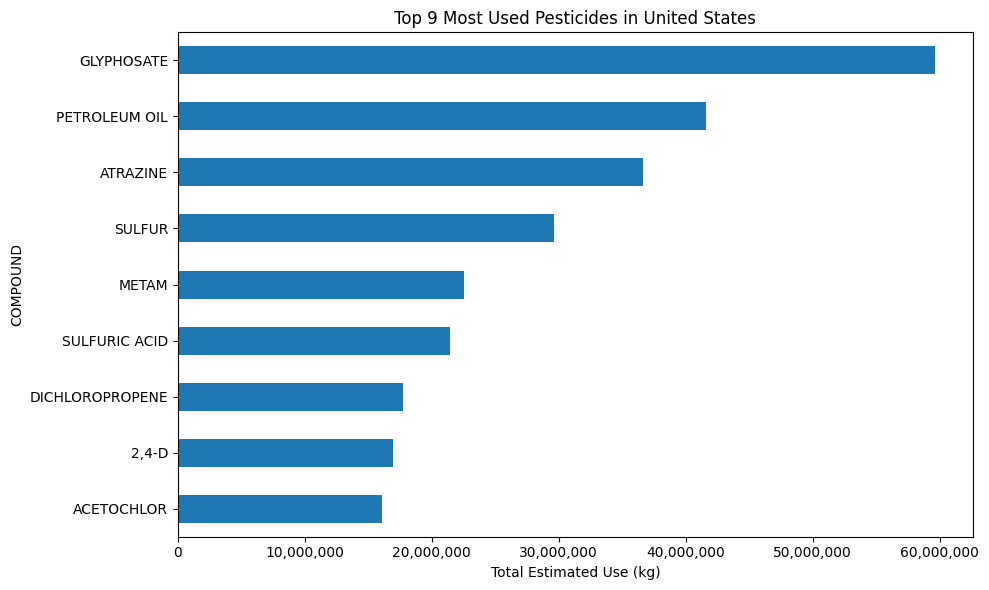

In [33]:
ax = top9.sort_values().plot(kind="barh", figsize=(10,6))

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Top 9 Most Used Pesticides in United States")
plt.xlabel("Total Estimated Use (kg)")

plt.tight_layout()
plt.show()

SPECIFIC PESTICIDE USE GRAPHS

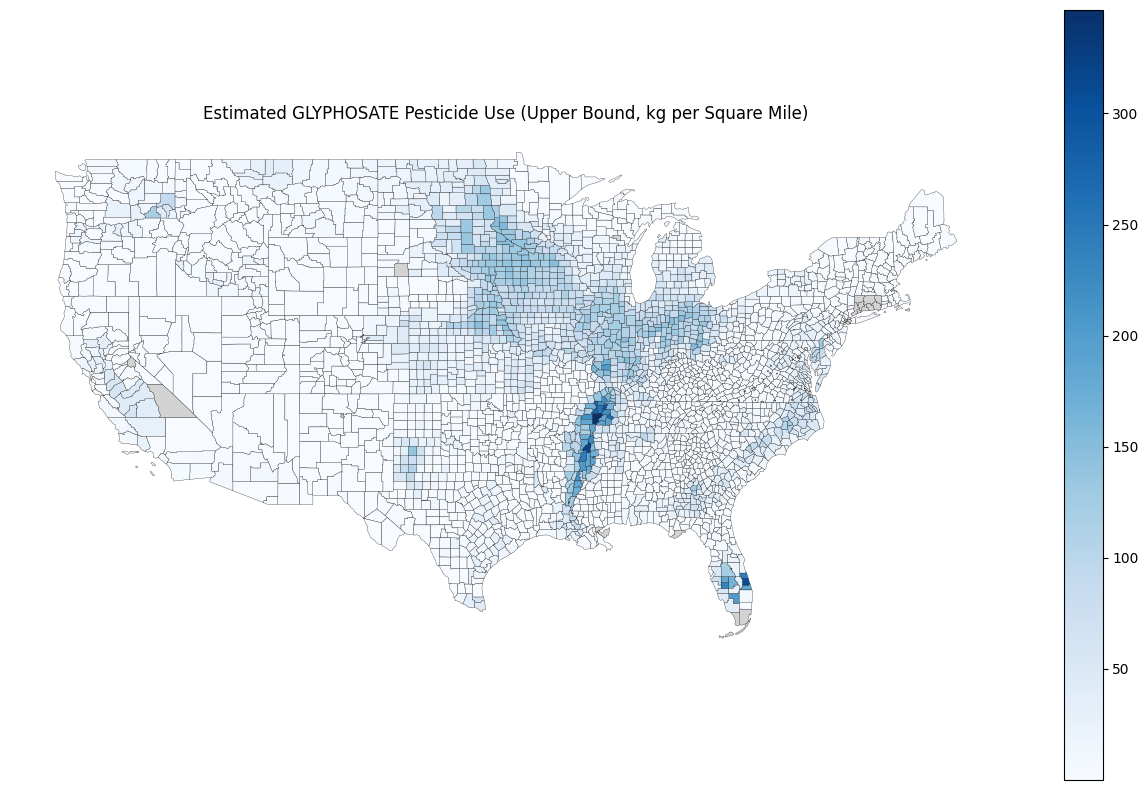

In [34]:
# Filter pesticide data to GLYPHOSATE
gly = merged_df[merged_df["COMPOUND"] == "GLYPHOSATE"].copy()

# Make sure needed columns are numeric
gly["EPEST_HIGH_KG"] = pd.to_numeric(gly["EPEST_HIGH_KG"])
gly["area_sqmi"] = pd.to_numeric(gly["area_sqmi"])

# Compute kg per square mile
gly["KG_PER_SQ_MILE"] = gly["EPEST_HIGH_KG"] / gly["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge GLYPHOSATE values onto map
gdf2 = counties.merge(gly, on="GEOID", how="left")

# Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf2.plot(
    column="KG_PER_SQ_MILE",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated GLYPHOSATE Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

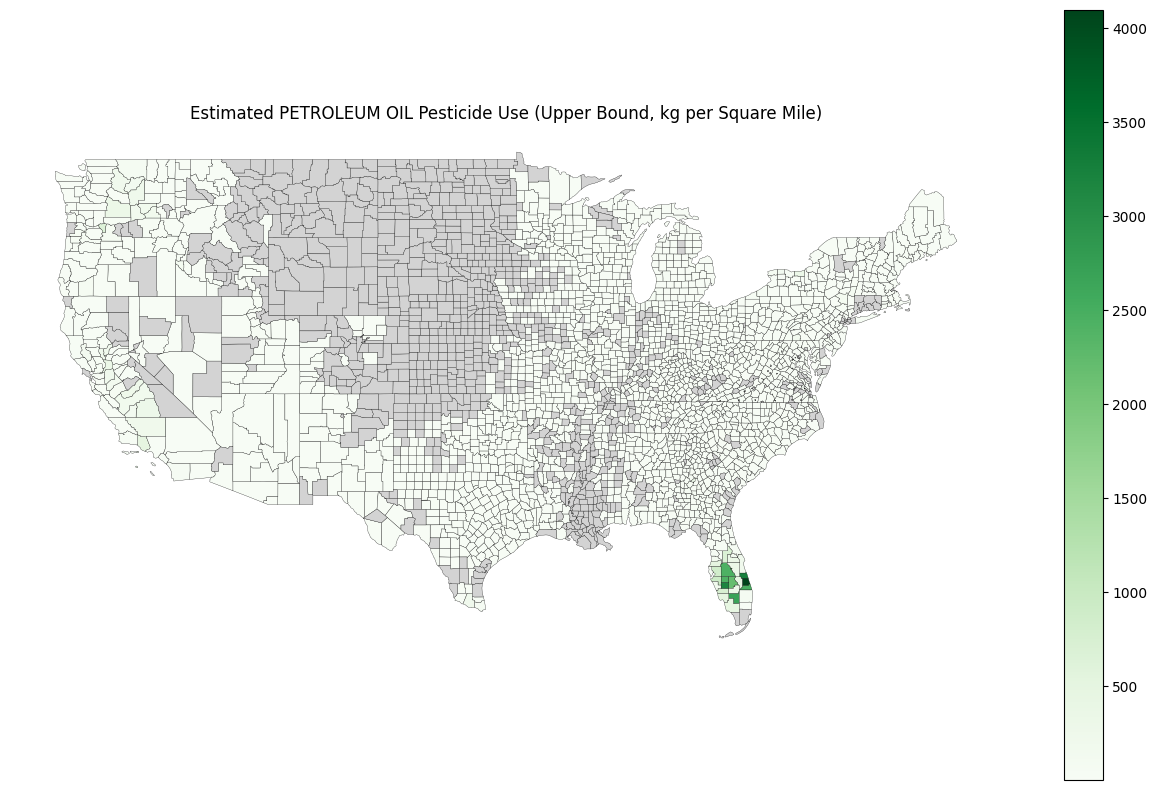

In [35]:
# Filter pesticide data to PETROLEUM OIL
pet = merged_df[merged_df["COMPOUND"] == "PETROLEUM OIL"].copy()

# Make sure needed columns are numeric
pet["EPEST_HIGH_KG"] = pd.to_numeric(pet["EPEST_HIGH_KG"])
pet["area_sqmi"] = pd.to_numeric(pet["area_sqmi"])

# Compute kg per square mile
pet["KG_PER_SQ_MILE"] = pet["EPEST_HIGH_KG"] / pet["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge PETROLEUM OIL values onto map
gdf3 = counties.merge(pet, on="GEOID", how="left")

# Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf3.plot(
    column="KG_PER_SQ_MILE",
    cmap="Greens",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated PETROLEUM OIL Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

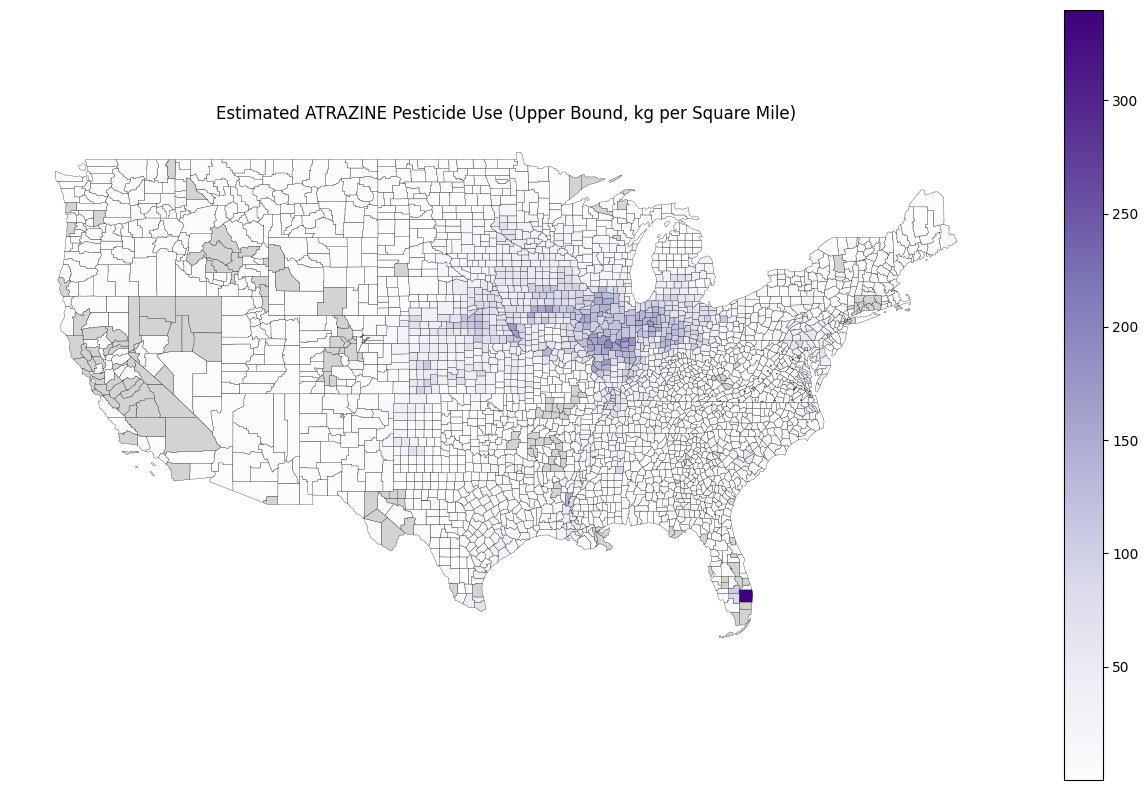

In [36]:
# Filter pesticide data to ATRAZINE
atr = merged_df[merged_df["COMPOUND"] == "ATRAZINE"].copy()

# Make sure needed columns are numeric
atr["EPEST_HIGH_KG"] = pd.to_numeric(atr["EPEST_HIGH_KG"])
atr["area_sqmi"] = pd.to_numeric(atr["area_sqmi"])

# Compute kg per square mile
atr["KG_PER_SQ_MILE"] = atr["EPEST_HIGH_KG"] / atr["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge ATRAZINE values onto map
gdf4 = counties.merge(atr, on="GEOID", how="left")

# Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf4.plot(
    column="KG_PER_SQ_MILE",
    cmap="Purples",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated ATRAZINE Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

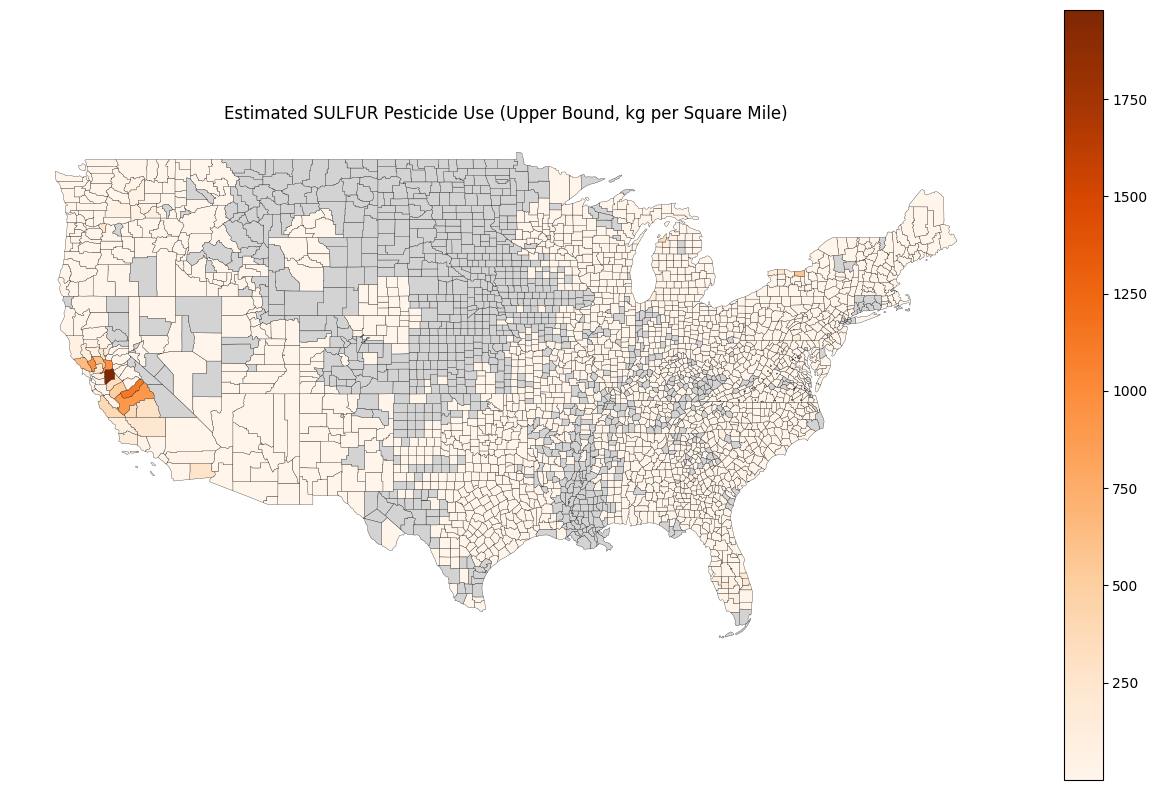

In [37]:
# Filter pesticide data to SULFUR
sul = merged_df[merged_df["COMPOUND"] == "SULFUR"].copy()

# Make sure needed columns are numeric
sul["EPEST_HIGH_KG"] = pd.to_numeric(sul["EPEST_HIGH_KG"])
sul["area_sqmi"] = pd.to_numeric(sul["area_sqmi"])

# Compute kg per square mile
sul["KG_PER_SQ_MILE"] = sul["EPEST_HIGH_KG"] / sul["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge SULFUR values onto map
gdf5 = counties.merge(sul, on="GEOID", how="left")

# Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf5.plot(
    column="KG_PER_SQ_MILE",
    cmap="Oranges",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated SULFUR Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

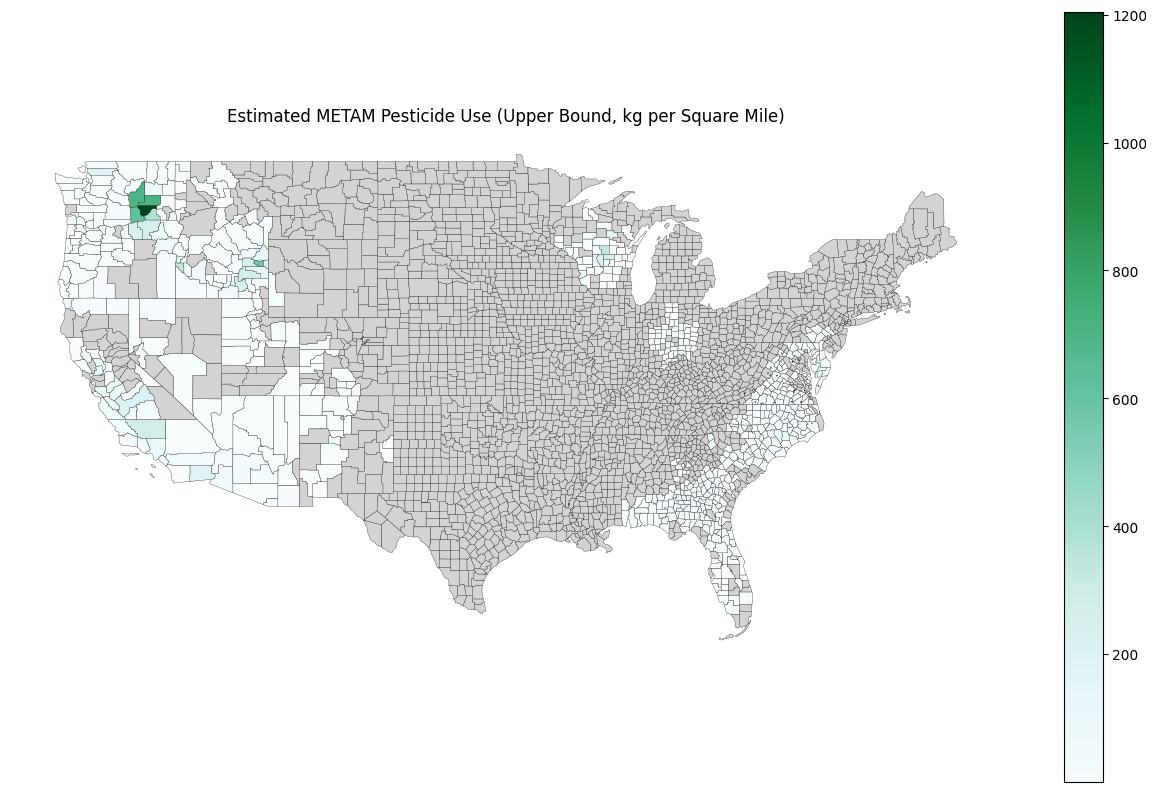

In [38]:
# Filter pesticide data to METAM
met = merged_df[merged_df["COMPOUND"] == "METAM"].copy()

# Make sure needed columns are numeric
met["EPEST_HIGH_KG"] = pd.to_numeric(met["EPEST_HIGH_KG"])
met["area_sqmi"] = pd.to_numeric(met["area_sqmi"])

# Compute kg per square mile
met["KG_PER_SQ_MILE"] = met["EPEST_HIGH_KG"] / met["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge METAM values onto map
gdf6 = counties.merge(met, on="GEOID", how="left")

# 5) Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf6.plot(
    column="KG_PER_SQ_MILE",
    cmap="BuGn",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated METAM Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

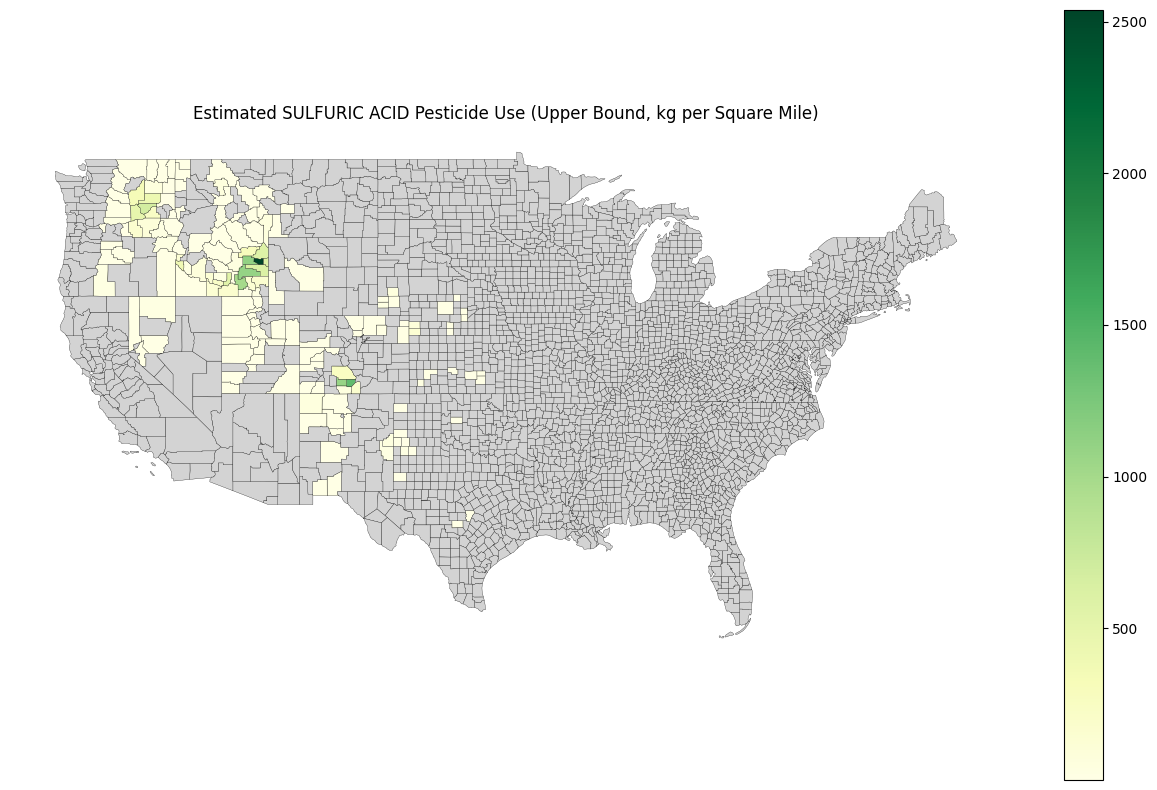

In [39]:
# Filter pesticide data to SULFURIC ACID
sula = merged_df[merged_df["COMPOUND"] == "SULFURIC ACID"].copy()

# Make sure needed columns are numeric
sula["EPEST_HIGH_KG"] = pd.to_numeric(sula["EPEST_HIGH_KG"])
sula["area_sqmi"] = pd.to_numeric(sula["area_sqmi"])

# Compute kg per square mile
sula["KG_PER_SQ_MILE"] = sula["EPEST_HIGH_KG"] / sula["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge SULFURIC ACID values onto map
gdf7 = counties.merge(sula, on="GEOID", how="left")

# 5) Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf7.plot(
    column="KG_PER_SQ_MILE",
    cmap="YlGn",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated SULFURIC ACID Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

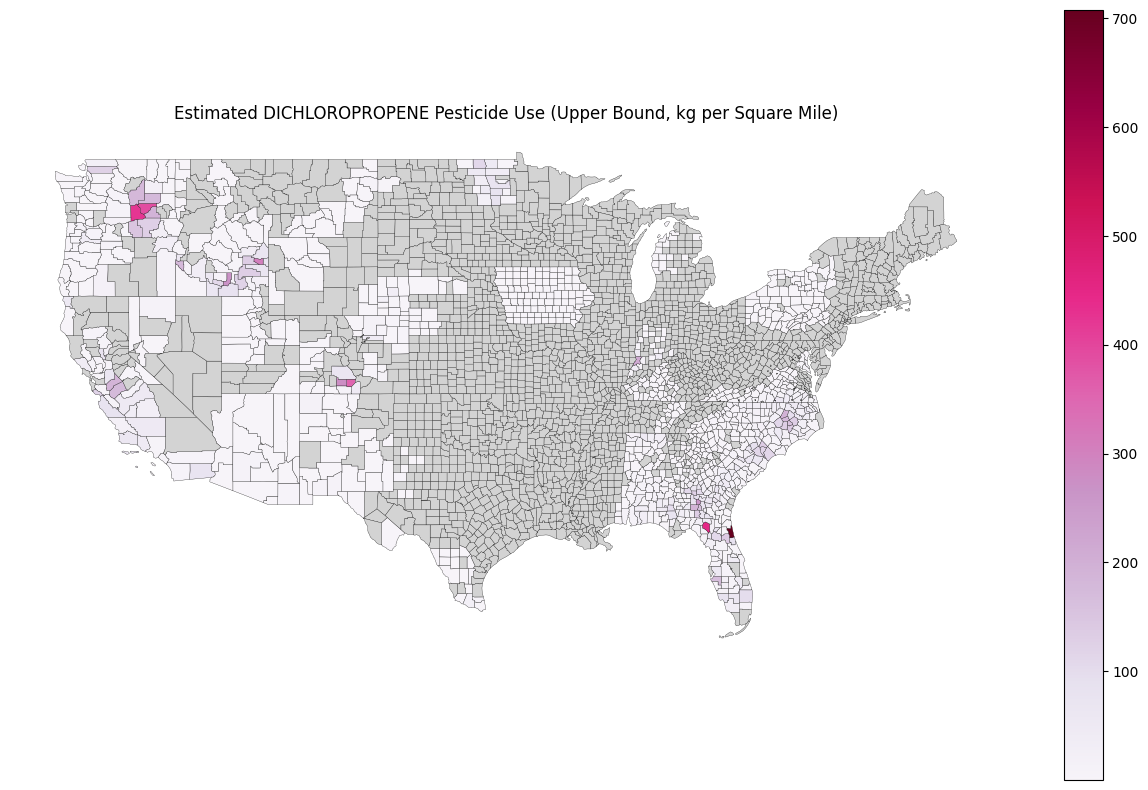

In [40]:
# Filter pesticide data to DICHLOROPROPENE
dic = merged_df[merged_df["COMPOUND"] == "DICHLOROPROPENE"].copy()

# Make sure needed columns are numeric
dic["EPEST_HIGH_KG"] = pd.to_numeric(dic["EPEST_HIGH_KG"])
dic["area_sqmi"] = pd.to_numeric(dic["area_sqmi"])

# Compute kg per square mile
dic["KG_PER_SQ_MILE"] = dic["EPEST_HIGH_KG"] / dic["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge DICHLOROPROPENE values onto map
gdf8 = counties.merge(dic, on="GEOID", how="left")

# Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf8.plot(
    column="KG_PER_SQ_MILE",
    cmap="PuRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated DICHLOROPROPENE Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

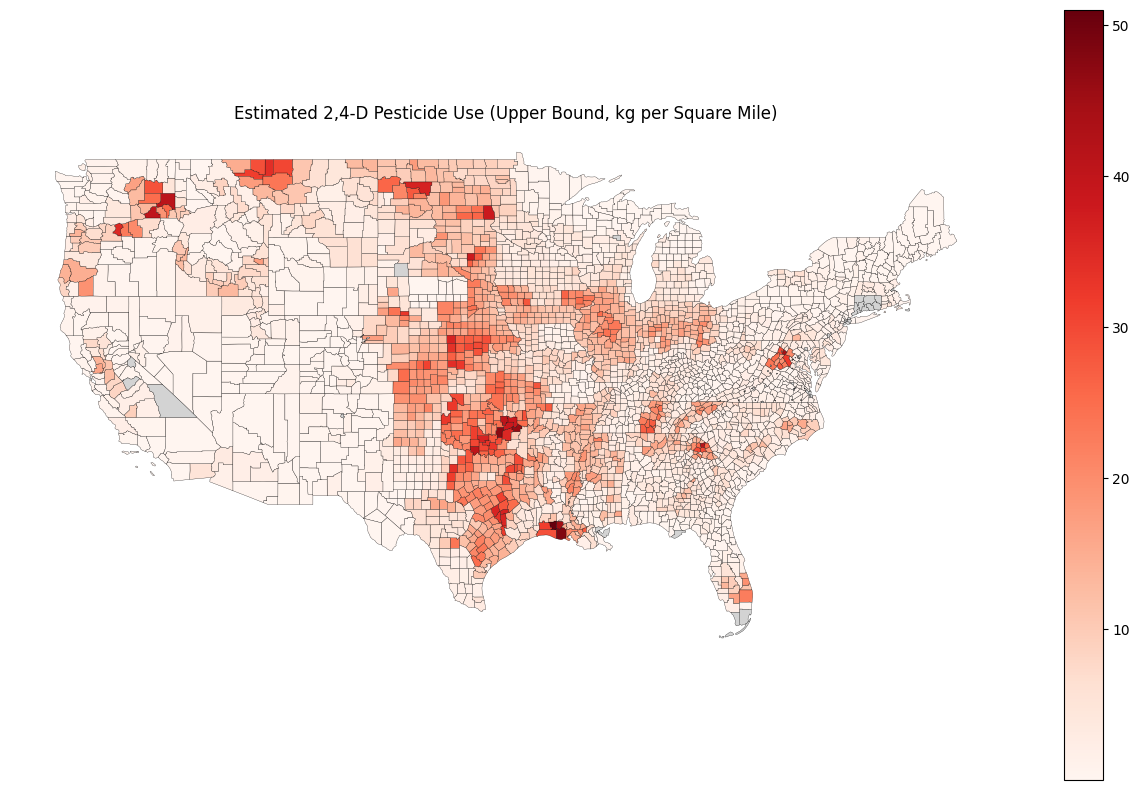

In [41]:
# Filter pesticide data to 2,4-D
d24 = merged_df[merged_df["COMPOUND"] == "2,4-D"].copy()

# Make sure needed columns are numeric
d24["EPEST_HIGH_KG"] = pd.to_numeric(d24["EPEST_HIGH_KG"])
d24["area_sqmi"] = pd.to_numeric(d24["area_sqmi"])

# Compute kg per square mile
d24["KG_PER_SQ_MILE"] = d24["EPEST_HIGH_KG"] / d24["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge 2,4-D values onto map
gdf1 = counties.merge(d24, on="GEOID", how="left")


# Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf1.plot(
    column="KG_PER_SQ_MILE",
    cmap="Reds",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated 2,4-D Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

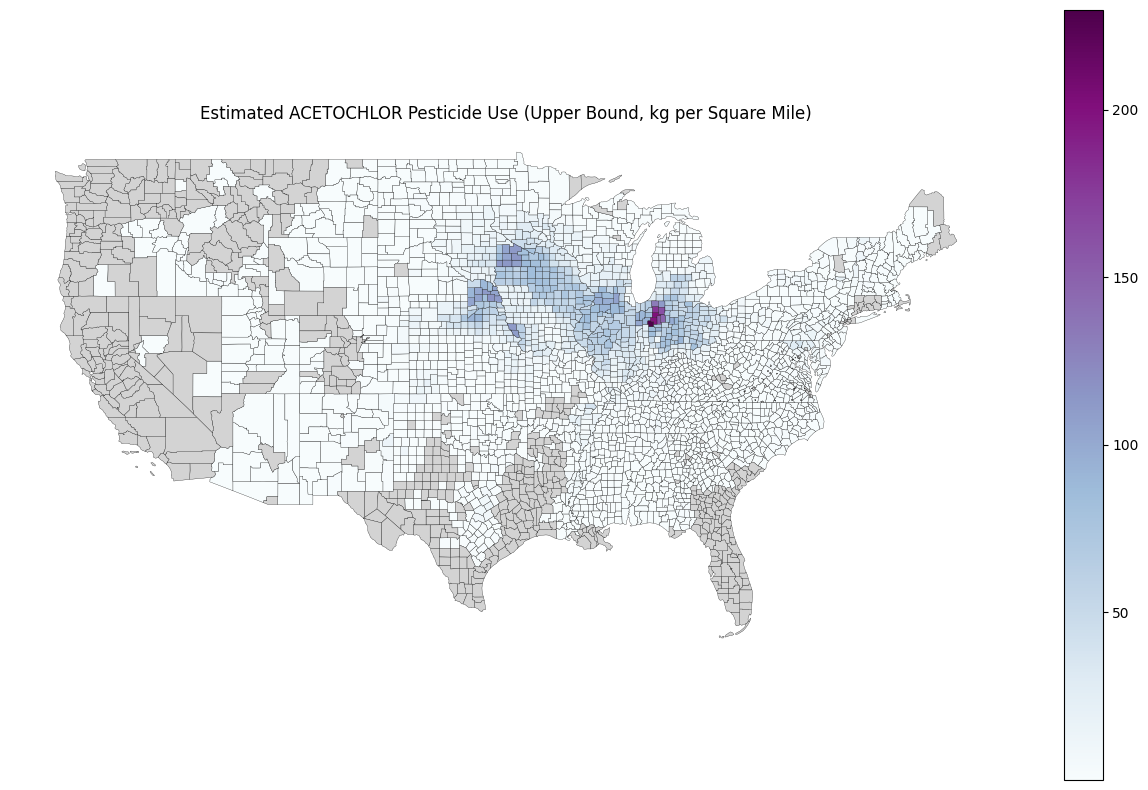

In [42]:
# Filter pesticide data to ACETOCHLOR
ace = merged_df[merged_df["COMPOUND"] == "ACETOCHLOR"].copy()

# Make sure needed columns are numeric
ace["EPEST_HIGH_KG"] = pd.to_numeric(ace["EPEST_HIGH_KG"])
ace["area_sqmi"] = pd.to_numeric(ace["area_sqmi"])

# Compute kg per square mile
ace["KG_PER_SQ_MILE"] = ace["EPEST_HIGH_KG"] / ace["area_sqmi"]

# Load county boundaries
counties = gpd.read_file(county_url)

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()


# Merge ACETOCHLOR values onto map
gdf9 = counties.merge(ace, on="GEOID", how="left")

# Plot choropleth
fig, ax = plt.subplots(figsize=(16, 10))

gdf9.plot(
    column="KG_PER_SQ_MILE",
    cmap="BuPu",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgray", "label": "No data"},
    ax=ax
)

ax.set_title("Estimated ACETOCHLOR Pesticide Use (Upper Bound, kg per Square Mile)")
ax.axis("off")

plt.show()

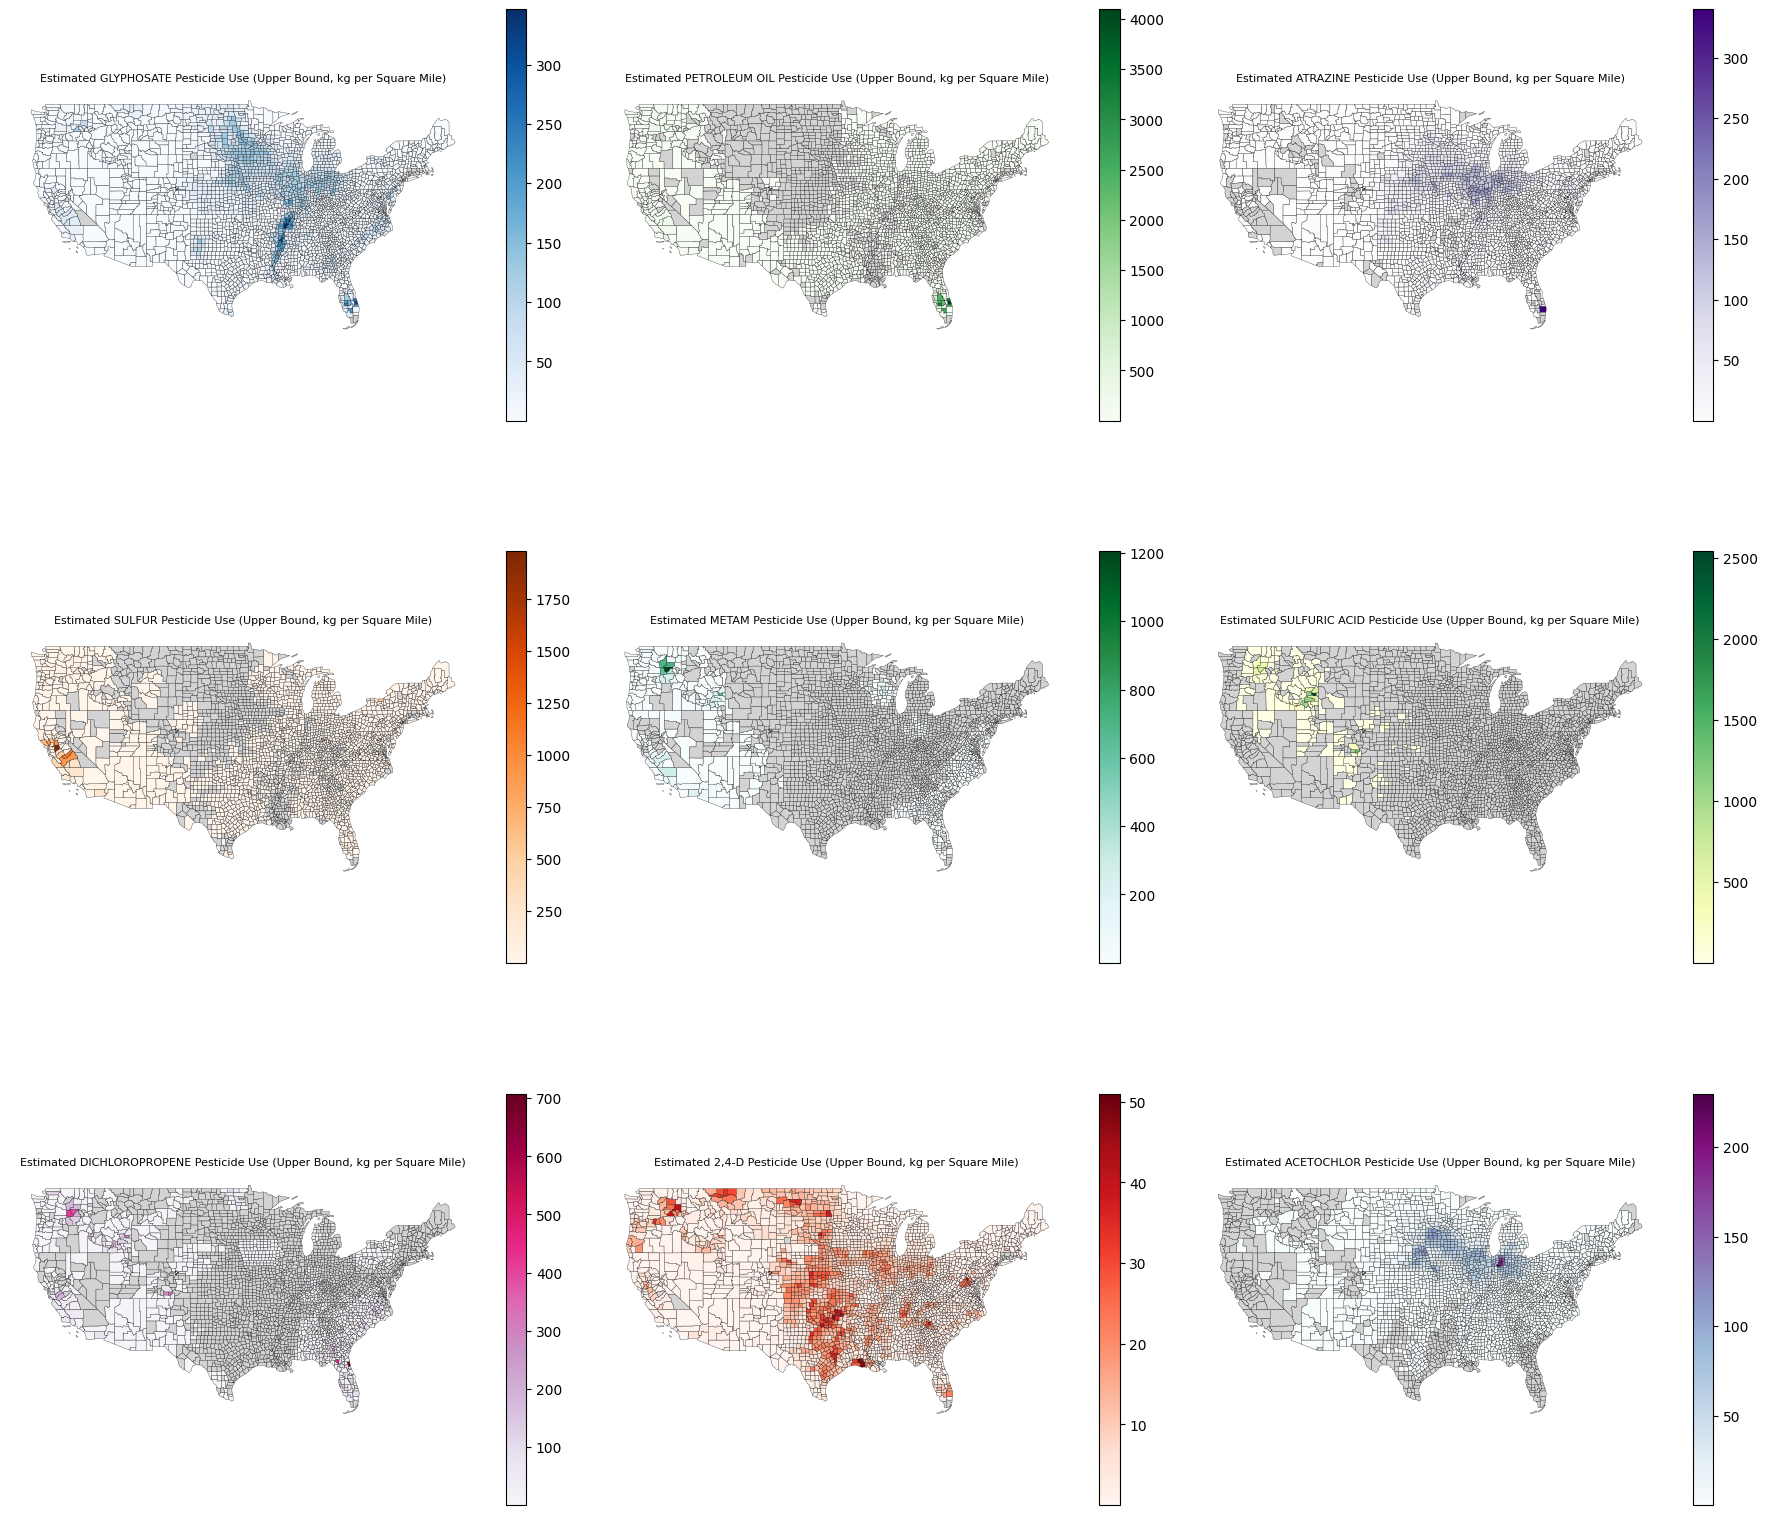

In [43]:
# All the maps in order by overall prevalence
gdfs = [gdf2, gdf3, gdf4, gdf5, gdf6, gdf7, gdf8, gdf1, gdf9]
titles = ["Estimated GLYPHOSATE Pesticide Use (Upper Bound, kg per Square Mile)", "Estimated PETROLEUM OIL Pesticide Use (Upper Bound, kg per Square Mile)", "Estimated ATRAZINE Pesticide Use (Upper Bound, kg per Square Mile)", "Estimated SULFUR Pesticide Use (Upper Bound, kg per Square Mile)", "Estimated METAM Pesticide Use (Upper Bound, kg per Square Mile)", "Estimated SULFURIC ACID Pesticide Use (Upper Bound, kg per Square Mile)", "Estimated DICHLOROPROPENE Pesticide Use (Upper Bound, kg per Square Mile)", "Estimated 2,4-D Pesticide Use (Upper Bound, kg per Square Mile)", "Estimated ACETOCHLOR Pesticide Use (Upper Bound, kg per Square Mile)"]
colors = ["Blues", "Greens", "Purples", "Oranges", "BuGn", "YlGn", "PuRd", "Reds", "BuPu"]

# Fix geometries
# Each map is a collection of individual county objects
# When you resize, causes breaks when assembling them into the map -> this fixes them
for i in range(len(gdfs)):
    gdfs[i] = gdfs[i].copy()
    gdfs[i]["geometry"] = gdfs[i].buffer(0)

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for i, gdf in enumerate(gdfs):
    gdf.plot(
        column="KG_PER_SQ_MILE",
        cmap=colors[i],
        linewidth=0.2,
        edgecolor="black",
        missing_kwds={"color": "lightgray"},
        ax=axes[i],
        legend=True,
        legend_kwds={
            "shrink": 0.6,
        }
    )

    axes[i].set_title(titles[i], fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

REVISIONS : INTERACTIVE DROPDOWN AND HEATMAP

In [44]:
#INTERACTIVE DROPDOWN
# putting some of the choropleth maps in some kind of interactive dropdown to directly compare them

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Fix geometries
# Each map is a collection of individual county objects
# When you resize, causes breaks when assembling them into the map -> this fixes them
gdfs = [gdf1, gdf2, gdf3, gdf4, gdf5, gdf6, gdf7, gdf8, gdf9]
# created colors for reprinting purposes
colors = ["Blues", "Greens", "Purples", "Oranges", "BuGn", "YlGn", "PuRd", "Reds", "BuPu"]
for i in range(len(gdfs)):
    gdfs[i] = gdfs[i].copy()
    gdfs[i]["geometry"] = gdfs[i].buffer(0)

# if certain choice was selected, function returns cloropleth object with corresponding color
def generate_data(choice):
  if choice == "GLYPHOSATE":
    return gdf2, "Blues"
  elif choice == "PETROLEUM OIL":
    return gdf3, "Greens"
  elif choice == "ATRAZINE":
    return gdf4, "Purples"
  elif choice == "SULFUR":
    return gdf5, "Oranges"
  elif choice == "METAM":
    return gdf6, "BuGn"
  elif choice == "SULFURIC ACID":
    return gdf7, "YlGn"
  elif choice == "DICHLOROPROPENE":
    return gdf8, "PuRd"
  elif choice == "2,4-D":
    return gdf1, "Reds"
  elif choice == "ACETOCHLOR":
    return gdf9, "BuPu"


# everytime new selection occurs, function updates the viz generated
def update_dropdown(change):
    # changes data to new viz selected
    selected_pesticide = change['new']
    gdf_to_plot, cmap_to_use = generate_data(selected_pesticide)

    if gdf_to_plot is None:
        # Handle case where an invalid pesticide is selected (shouldn't happen with dropdown)
        with output:
            clear_output(wait=True)
            print("No data available for the selected pesticide.")
        return

    # with keyword keeps viz in that exact box-- viz displays exactly as its shown
    with output:
      #clears old map
        clear_output(wait=True)
        #replots new map with parameters used in prevous code
        fig, ax = plt.subplots(figsize=(10, 6))
        gdf_to_plot.plot(ax=ax,
                  column= "KG_PER_SQ_MILE",
                  legend=True,
                  cmap=cmap_to_use,
                  linewidth=0.2,
                  edgecolor="black",
                  missing_kwds={"color": "lightgray"}
                  )
        # creates title and replaces it with selected pesticide
        plt.title(f"Map for {selected_pesticide}")
        # shows new graph
        plt.show()
#create dropdown from ipywigets (Jupyter Notebook: https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html)
dropdown = widgets.Dropdown(
    options = ["GLYPHOSATE", "PETROLEUM OIL", "ATRAZINE", "SULFUR", "METAM", "SULFURIC ACID", "DICHLOROPROPENE", "2,4-D", "ACETOCHLOR"],
    value = "GLYPHOSATE",
    description = "Select Pesticide Map:",
    style={'description_width': 'initial'})
# create output widget to create new output when dropdown is selected
output = widgets.Output()
# display command displays new output from dropdown
display(dropdown, output)
#sets up handler tobe called to update dropdown when dropdown changes
dropdown.observe(update_dropdown, names='value')
# updates dropdown object with new value
update_dropdown({'new': dropdown.value})

Dropdown(description='Select Pesticide Map:', options=('GLYPHOSATE', 'PETROLEUM OIL', 'ATRAZINE', 'SULFUR', 'M…

Output()

In [45]:
#upload parkensons_pesticide_gene.xlsx
uploaded = files.upload()
gene_df = pd.read_excel("parkensons_pesticide_gene.xlsx")

Saving parkensons_pesticide_gene.xlsx to parkensons_pesticide_gene.xlsx


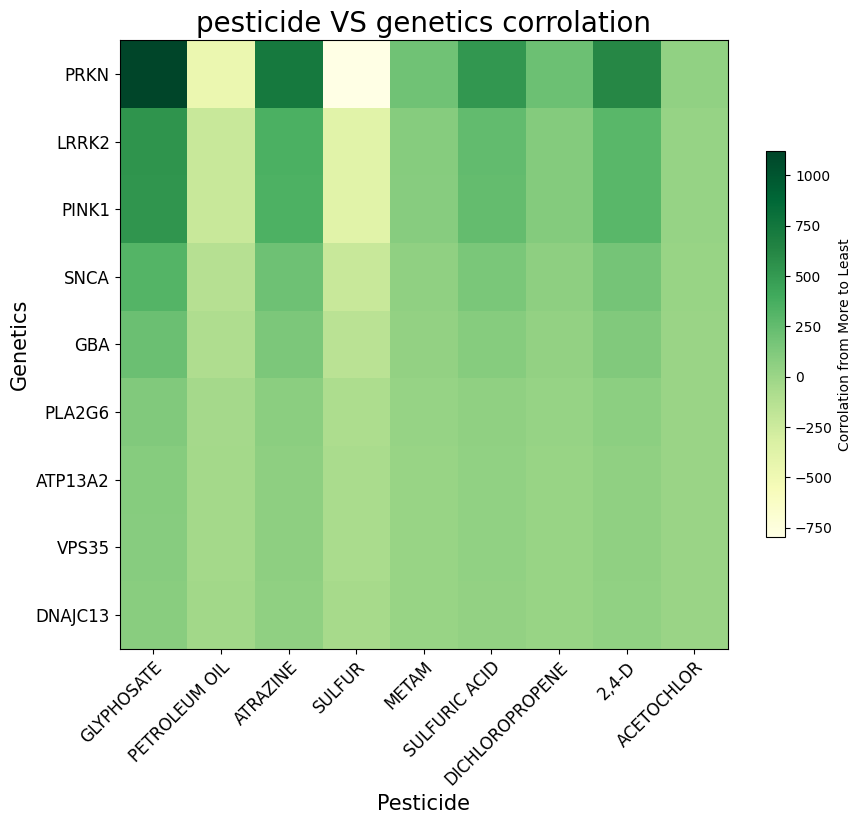

In [46]:
import math
import numpy as np
#HEATMAP
#Derive correlation coefficients from different genes and pesticides, maybe generate a heatmap with genes on one axis, pesticides on the other.
#parkensons_pesticide_gene.xlsx FILE: https://docs.google.com/spreadsheets/d/1uxolfveqI_4DqvQqaRjHMQcT1RmhX45zXV2ey3G5H_M/edit?usp=sharing

#define gene title and coorolation score for heatmap values and y-axis
# In the spreadsheet, I took the log10 value of pesticide value to make the distinction between value more obvious on the heatmap
# I then rounded those values to 2 decimal places
gene_title = gene_df["Gene name"]
gene_corr = gene_df['Gene scores']

#compress number of pesticide use by log10 to make it simular to gene scores
# I took the log10 value of pesticide value to make the distinction between value more obvious on the heatmap
# because there are so many values compared ot the 9 gene scores, I had to take the adverage of all the log10 values
result = np.log10(gly['KG_PER_SQ_MILE']).mean()
result2 = np.log10(pet['KG_PER_SQ_MILE']).mean()
result3 = np.log10(atr['KG_PER_SQ_MILE']).mean()
result4 = np.log10(sul['KG_PER_SQ_MILE']).mean()
result5 = np.log10(met['KG_PER_SQ_MILE']).mean()
result6 = np.log10(sula['KG_PER_SQ_MILE']).mean()
result7 = np.log10(dic['KG_PER_SQ_MILE']).mean()
result8 = np.log10(d24['KG_PER_SQ_MILE']).mean()
result9 = np.log10(ace['KG_PER_SQ_MILE']).mean()

#create list of corrolation scores and title for x-axis
pest_corr = [result, result2, result3, result4, result5, result6, result7, result8, result9]
pest_title = ["GLYPHOSATE", "PETROLEUM OIL", "ATRAZINE", "SULFUR", "METAM", "SULFURIC ACID", "DICHLOROPROPENE", "2,4-D", "ACETOCHLOR"]

# Create a 2D array for the heatmap
# Assuming an outer product represents the intended 'correlation' or interaction for visualization
correlation_matrix = np.outer(gene_corr, pest_corr)

# plots heapmap using tutorial from matplotlib website : https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
fig, ax = plt.subplots( figsize=(9,9))
im = ax.imshow(correlation_matrix, cmap="YlGn")
# create colorbar to represnet colormap values
cbar = ax.figure.colorbar(im, ax = ax, shrink=0.5, label="Corrolation from More to Least")
# add tick labels
ax.set_xticks(np.arange(len(pest_title)), labels=pest_title, size=12)
ax.set_yticks(np.arange(len(gene_title)), labels=gene_title,size=12)
# Rotate the tick labels to be more legible
plt.setp(ax.get_xticklabels(), rotation = 45, ha = "right", rotation_mode = "anchor")
# create layout and titles for x-axis and y-axis
ax.set_title("pesticide VS genetics corrolation", size=20)
ax.set_xlabel("Pesticide", size=15)
ax.set_ylabel("Genetics", size=15)
fig.tight_layout()
#shows heatmap
plt.show()

Glyph graph

In [47]:
# Uploading Parkinson's Disease pesticides by county and country area
uploaded = files.upload()


Saving county_area.xlsx to county_area (2).xlsx


In [51]:
# Uploading Parkinson's Disease pesticides by county and country area
uploaded = files.upload()


Saving HDPulse_data_export.csv to HDPulse_data_export.csv


In [49]:

# Load map data from census
county_url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_county_20m.zip"
# Read the files from the URL to get the counties
counties = gpd.read_file(county_url)

# Remove territories that are not part of United States
exclude = ["60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()

# Columns we want
area_df = counties[["STATEFP", "COUNTYFP", "NAME", "GEOID", "ALAND"]].copy()

# Convert land area to square miles
area_df["area_sqmi"] = area_df["ALAND"] / 2_589_988.11

# Save to Excel
area_df.to_excel("county_area.xlsx", index=False)

In [52]:
# Put 3 files into dataframes
area_df = pd.read_excel("county_area.xlsx")
pest_df = pd.read_excel("pesticides_by_county.xlsx")
# Added skiprows=5 and sep=',' to handle potential header/metadata lines and ensure correct delimiter
air_df = pd.read_csv("HDPulse_data_export.csv", skiprows=5, sep=',')

# Filter out the "United States" row (FIPS 0) and missing values
air_df = air_df[air_df['FIPS'] > 0].dropna(subset=['FIPS'])
# Convert float FIPS to 5-digit string GEOID
air_df["GEOID"] = air_df["FIPS"].astype(int).astype(str).str.zfill(5)
# Rename the pollution column to something shorter in air_df
air_df = air_df.rename(columns={'Micrograms per cubic meter (PM2.5)(1)': 'PM2_5'})

# Add leading zeros and combine to create GEOIDs for pest_df
pest_df["STATE_FIPS_CODE"] = pest_df["STATE_FIPS_CODE"].astype(str).str.zfill(2)
pest_df["COUNTY_FIPS_CODE"] = pest_df["COUNTY_FIPS_CODE"].astype(str).str.zfill(3)
pest_df["GEOID"] = pest_df["STATE_FIPS_CODE"] + pest_df["COUNTY_FIPS_CODE"]

# Convert GEOID to string for area so the merge can be done
area_df["GEOID"] = area_df["GEOID"].astype(str).str.zfill(5)

# Merge area into pesticide table
merged_df = pest_df.merge(
    area_df[["GEOID", "NAME", "ALAND", "area_sqmi"]],
    on="GEOID",
    how="left"
)

# Merge in the Air Pollution data with pesticide data into one table
final_df = merged_df.merge(
    air_df[["GEOID", "PM2_5"]],
    on="GEOID",
    how="left"
)


In [53]:

# Filter pesticide data to ATRAZINE and SIMAZINE
atr = merged_df[merged_df["COMPOUND"] == "ATRAZINE"].copy()
sim = merged_df[merged_df["COMPOUND"] == "SIMAZINE"].copy()

# Make sure needed columns are numeric
atr["EPEST_HIGH_KG"] = pd.to_numeric(atr["EPEST_HIGH_KG"])
atr["area_sqmi"] = pd.to_numeric(atr["area_sqmi"])

sim["EPEST_HIGH_KG"] = pd.to_numeric(sim["EPEST_HIGH_KG"])
sim["area_sqmi"] = pd.to_numeric(sim["area_sqmi"])

# Compute kg per square mile
atr["KG_PER_SQ_MILE"] = atr["EPEST_HIGH_KG"] / atr["area_sqmi"]
sim["KG_PER_SQ_MILE"] = sim["EPEST_HIGH_KG"] / sim["area_sqmi"]

# Remove territories not in data
exclude = ["02", "15", "60", "66", "69", "72", "78"]
counties = counties[~counties["STATEFP"].isin(exclude)].copy()

# Merge ATRAZINE and SIMAZINE values onto map sequentially
map = counties.merge(atr, on="GEOID", how="left", suffixes=('_county', '_atr'))
map = map.merge(sim, on="GEOID", how="left", suffixes=('_atr', '_sim'))

# Prepare air pollution data for merging
# Assuming air_df is already processed for unique GEOIDs in cell VbhmzSINYPKS
air_pollution_for_merge = air_df[['GEOID', 'PM2_5']].drop_duplicates(subset=['GEOID'])

# Merge air pollution data into the map GeoDataFrame
map = map.merge(air_pollution_for_merge, on="GEOID", how="left")

# EPSG:3857 (Web Mercator) is a projected coordinate system for rendering maps
# I needed to locate the values into data points in order to plot points on the map
# Using map.to_crs to do so
map_projected = map.to_crs(epsg=3857)


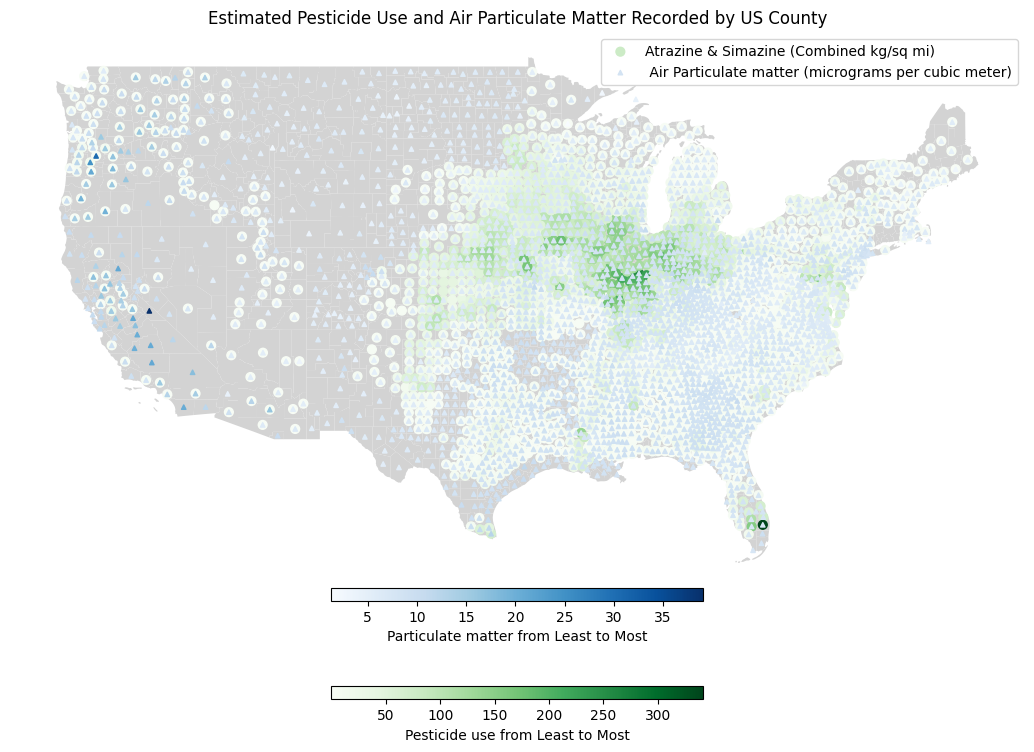

In [54]:

# 1. Filter for counties where both are present
both_present = map_projected[
    (map_projected['KG_PER_SQ_MILE_atr'] > 0) &
    (map_projected['KG_PER_SQ_MILE_sim'] > 0)
].copy() # use .copy() to avoid SettingWithCopy warnings

# 2. Create a combined value for the color intensity
# Adding them together represents the total pesticide load for the color scale
both_present['combined_load'] = both_present['KG_PER_SQ_MILE_atr'] + both_present['KG_PER_SQ_MILE_sim']

# Prepare air pollution data for merging
# Assuming air_df is already processed for unique GEOIDs in cell VbhmzSINYPKS
air_pollution_for_merge = air_df[['GEOID', 'PM2_5']].drop_duplicates(subset=['GEOID'])

# Merge air pollution data into the map GeoDataFrame
#map = map.merge(air_pollution_for_merge, on="GEOID", how="left")

# 5) Plot map
fig, ax = plt.subplots(figsize=(16, 10))

# Plot the base map (lightgray counties)
map_projected.plot(
    ax=ax,
    color='lightgray'
)

# 3. Plot using the new combined column
scatter_plot = ax.scatter(
    both_present.geometry.centroid.x,
    both_present.geometry.centroid.y,
    c=both_present['combined_load'],  # Use the calculated sum here
    cmap="Greens",
    marker="o",
    s=40,
    label="Atrazine & Simazine (Combined kg/sq mi)"
)

#plot countries with air pollution as yellow points
air_present = map_projected[map_projected['PM2_5'].notna()]
scatter_plot2 = ax.scatter(air_present.geometry.centroid.x,
           air_present.geometry.centroid.y,
           c = air_present['PM2_5'],
           cmap = "Blues",
           marker = "^",
           s =10,
           label = " Air Particulate matter (micrograms per cubic meter)")

#create colorbars
cbar = fig.colorbar(scatter_plot, ax = ax, pad =0, shrink=0.3,orientation = "horizontal",location = "bottom", aspect = 30, label="Pesticide use from Least to Most")
cbar2 = fig.colorbar(scatter_plot2, ax = ax, pad = 0,shrink=0.3,orientation = "horizontal", location = "bottom", aspect = 30,label="Particulate matter from Least to Most")
#set titles and turn of axis
#create legends and show plot
ax.set_title("Estimated Pesticide Use and Air Particulate Matter Recorded by US County")
ax.axis("off")
ax.legend()
plt.show()